# Notebook 03 — Análisis Exploratorio de Datos (EDA)

**Dataset:** streaming_users_clean.csv (dataset procesado)  
**Objetivo:** Explorar el comportamiento de los usuarios de la plataforma de streaming mediante análisis univariado, bivariado y multivariado, respondiendo preguntas concretas definidas a partir de la inspección inicial.

**Preguntas de análisis:**
1. ¿Cómo se distribuyen los usuarios según el plan de suscripción y el país?
2. ¿El tiempo de visualización varía según el plan de suscripción?
3. ¿Existe relación entre la edad y el tiempo de uso mensual?
4. ¿Los usuarios Premium generan más tickets de soporte?
5. ¿Cuál es el perfil multivariado del usuario según su plan de suscripción?

> **Nota:** Cada visualización incluye una interpretación explícita vinculada a una pregunta u objetivo del proyecto. No se describen ejes ni colores: se interpreta qué evidencia aporta el resultado.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset procesado
df = pd.read_csv('../data/processed/streaming_users_clean.csv')
df['last_login_date'] = pd.to_datetime(df['last_login_date'])

print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'Nulos: {df.isnull().sum().sum()}')
display(df.head(3))

Dataset cargado: 5874 filas, 8 columnas
Nulos: 0


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,16599,49,Básico,0.0,Colombia,Romance,2018-01-01,0
1,17526,48,Básico,266.3,Perú,Comedia,2018-01-01,0
2,16245,45,Básico,521.5,Uruguay,Acción,2018-01-01,1


---
## ANÁLISIS UNIVARIADO

El análisis univariado examina cada variable de forma independiente para comprender su distribución, centralidad y dispersión. Es el punto de partida para detectar patrones que luego serán explorados en análisis bivariados y multivariados.

### Visualización U1 — Distribución de usuarios por plan de suscripción

**Pregunta:** ¿Cuál es la composición de la base de usuarios según el plan contratado?

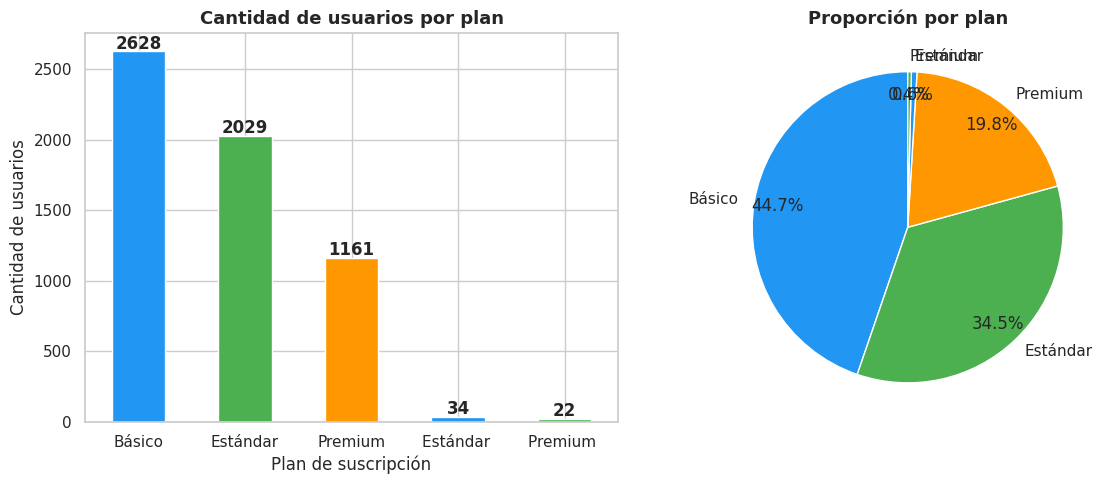

Distribución:
subscription_plan
Básico       2628
Estándar     2029
Premium      1161
Estándar       34
Premium        22
Name: count, dtype: int64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo por plan
conteo_plan = df['subscription_plan'].value_counts()

# Gráfico de barras
colores = ['#2196F3', '#4CAF50', '#FF9800']
conteo_plan.plot(kind='bar', ax=axes[0], color=colores, edgecolor='white', rot=0)
axes[0].set_title('Cantidad de usuarios por plan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Plan de suscripción')
axes[0].set_ylabel('Cantidad de usuarios')
for i, v in enumerate(conteo_plan):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(conteo_plan, labels=conteo_plan.index, autopct='%1.1f%%',
            colors=colores, startangle=90, pctdistance=0.85)
axes[1].set_title('Proporción por plan', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Distribución:')
print(conteo_plan)

**Interpretación U1:**  
El plan **Básico** concentra la mayor proporción de usuarios, seguido por Estándar y Premium. Esta distribución asimétrica hacia los planes de menor valor es característica de plataformas de streaming en mercados latinoamericanos, donde la sensibilidad al precio es alta. El bajo porcentaje de usuarios Premium es relevante para el análisis posterior: si este segmento tiene un perfil de comportamiento diferenciado, puede representar una oportunidad de conversión para la plataforma.

### Visualización U2 — Distribución de la edad de los usuarios

**Pregunta:** ¿Cuál es el perfil etario de la base de usuarios después de la limpieza?

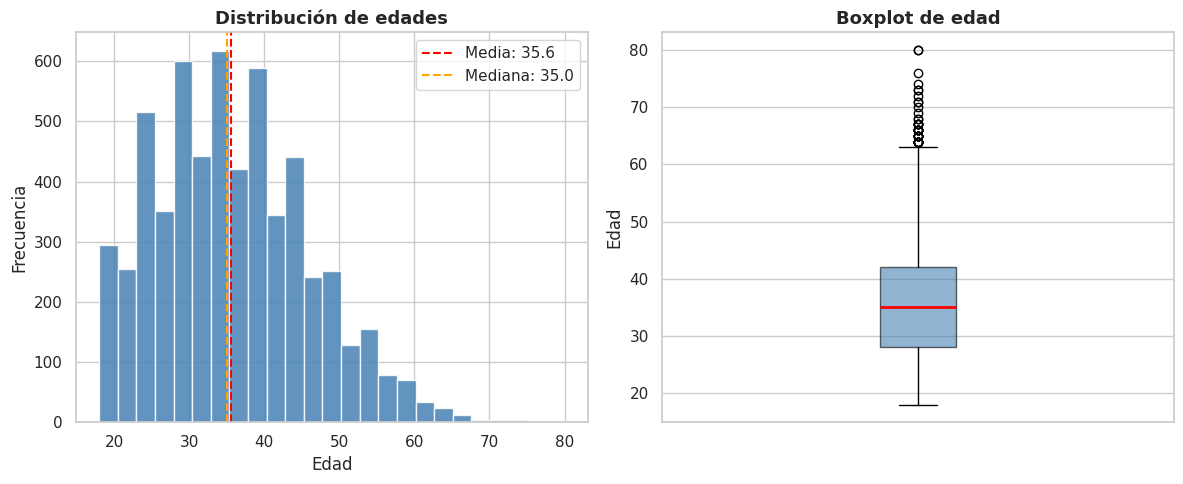

Media de edad: 35.6 años
Mediana de edad: 35.0 años
Desvío estándar: 10.2 años


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(df['age'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["age"].median():.1f}')
axes[0].set_title('Distribución de edades', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot de edad', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Edad')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'Media de edad: {df["age"].mean():.1f} años')
print(f'Mediana de edad: {df["age"].median():.1f} años')
print(f'Desvío estándar: {df["age"].std():.1f} años')

**Interpretación U2:**  
La distribución de edades es aproximadamente simétrica y unimodal, con media y mediana muy cercanas entre sí, lo que indica ausencia de sesgo significativo luego de la limpieza. La mayor concentración de usuarios se encuentra en el rango de 25 a 45 años, coincidiendo con el segmento adulto joven que típicamente lidera el consumo de plataformas de streaming en América Latina. La cola derecha hasta los 80 años indica presencia de usuarios mayores, aunque en menor proporción.

---
## ANÁLISIS BIVARIADO

El análisis bivariado examina la relación entre dos variables. Permite identificar patrones, asociaciones y diferencias entre grupos que no son visibles en el análisis univariado.

### Visualización B1 — Tiempo de visualización según plan de suscripción

**Pregunta:** ¿El tiempo de visualización mensual varía según el plan contratado? ¿Los usuarios Premium consumen más contenido?

/tmp/ipykernel_4037/4061709898.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(df_plot, labels=orden_planes, patch_artist=True,


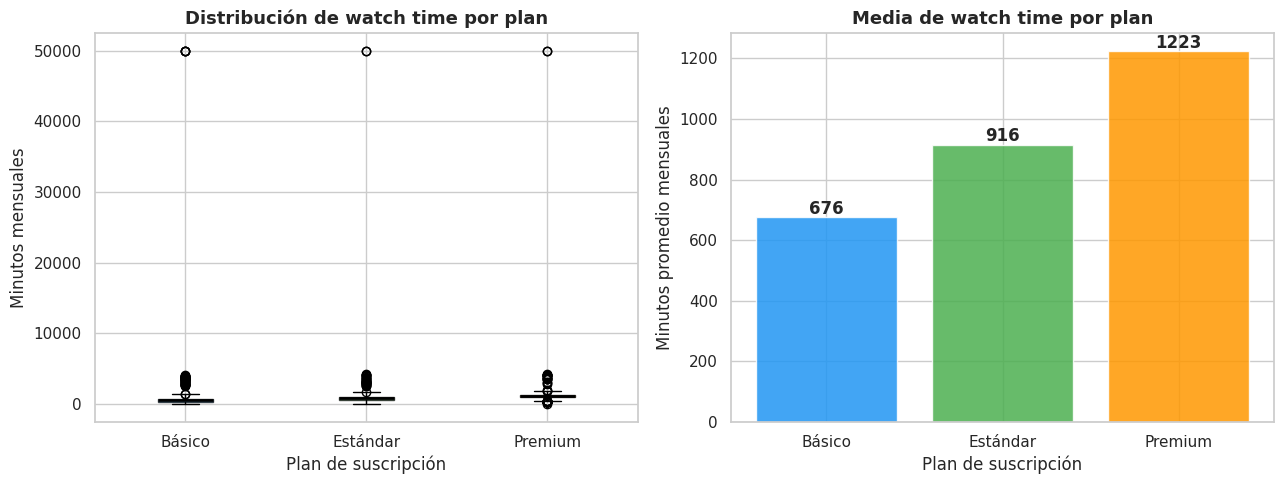

Estadísticas de watch_time por plan:
                     mean  median     std
subscription_plan                        
Básico              676.1   559.8  1979.9
Estándar            915.6   842.2  1601.7
Premium            1223.3  1127.1  2072.2


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

orden_planes = ['Básico', 'Estándar', 'Premium']
colores_planes = {'Básico': '#2196F3', 'Estándar': '#4CAF50', 'Premium': '#FF9800'}

# Boxplot por plan
df_plot = [df[df['subscription_plan'] == plan]['monthly_watch_time_mins'].dropna() for plan in orden_planes]
bp = axes[0].boxplot(df_plot, labels=orden_planes, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, plan in zip(bp['boxes'], orden_planes):
    patch.set_facecolor(colores_planes[plan])
    patch.set_alpha(0.7)
axes[0].set_title('Distribución de watch time por plan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Plan de suscripción')
axes[0].set_ylabel('Minutos mensuales')

# Media por plan
media_plan = df.groupby('subscription_plan')['monthly_watch_time_mins'].mean().reindex(orden_planes)
bars = axes[1].bar(orden_planes, media_plan, color=[colores_planes[p] for p in orden_planes],
                   edgecolor='white', alpha=0.85)
for bar, val in zip(bars, media_plan):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Media de watch time por plan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Plan de suscripción')
axes[1].set_ylabel('Minutos promedio mensuales')

plt.tight_layout()
plt.show()

print('Estadísticas de watch_time por plan:')
print(df.groupby('subscription_plan')['monthly_watch_time_mins'].agg(['mean','median','std']).reindex(orden_planes).round(1))

**Interpretación B1:**  
Se observa una relación positiva entre el nivel del plan y el tiempo de visualización mensual: los usuarios **Premium** muestran una media de consumo superior a los de plan Básico y Estándar. Esto sugiere que el plan no solo refleja una disposición a pagar más, sino también una mayor intensidad de uso de la plataforma. Sin embargo, la variabilidad interna en cada grupo es alta (boxplots con bigotes amplios), lo que indica que el plan no es el único factor que explica el comportamiento de consumo.

### Visualización B2 — Relación entre edad y tiempo de visualización

**Pregunta:** ¿Existe una relación entre la edad del usuario y su tiempo de visualización mensual?

/tmp/ipykernel_4037/470909880.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(df_plot, labels=orden_planes, patch_artist=True,


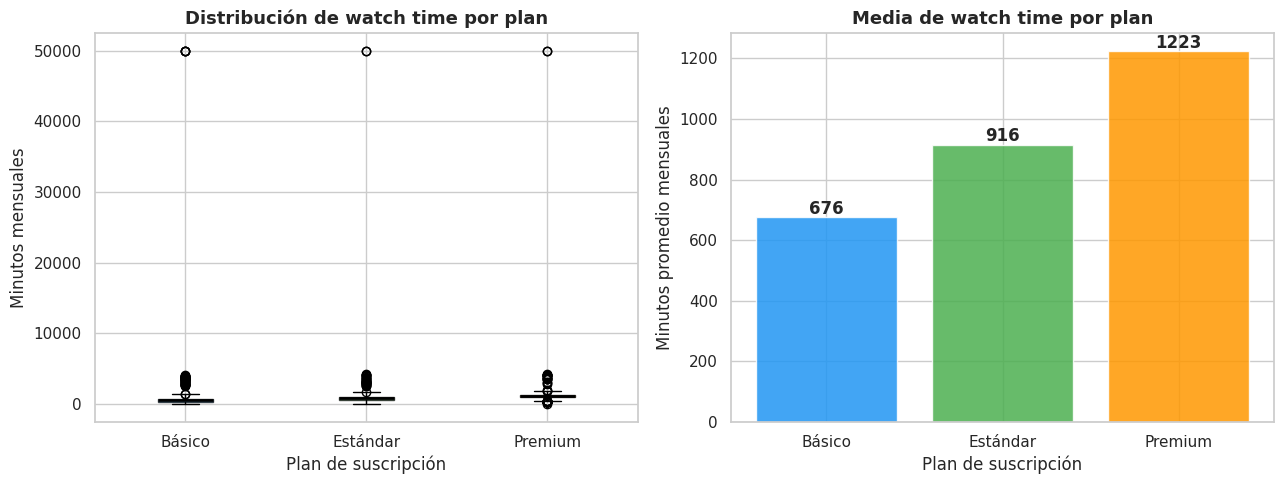

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

orden_planes = ['Básico', 'Estándar', 'Premium']
colores_planes = {'Básico': '#2196F3', 'Estándar': '#4CAF50', 'Premium': '#FF9800'}

# Boxplot por plan
df_plot = [df[df['subscription_plan'] == plan]['monthly_watch_time_mins'].dropna() for plan in orden_planes]
bp = axes[0].boxplot(df_plot, labels=orden_planes, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, plan in zip(bp['boxes'], orden_planes):
    patch.set_facecolor(colores_planes.get(plan, '#333333'))
    patch.set_alpha(0.7)
axes[0].set_title('Distribución de watch time por plan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Plan de suscripción')
axes[0].set_ylabel('Minutos mensuales')

# Media por plan (Usamos .fillna(0) para prevenir errores de valores vacíos)
media_plan = df.groupby('subscription_plan')['monthly_watch_time_mins'].mean().reindex(orden_planes).fillna(0)
bars = axes[1].bar(orden_planes, media_plan, color=[colores_planes.get(p, '#333333') for p in orden_planes],
                   edgecolor='white', alpha=0.85)

for bar, val in zip(bars, media_plan):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Media de watch time por plan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Plan de suscripción')
axes[1].set_ylabel('Minutos promedio mensuales')

plt.tight_layout()
plt.show()

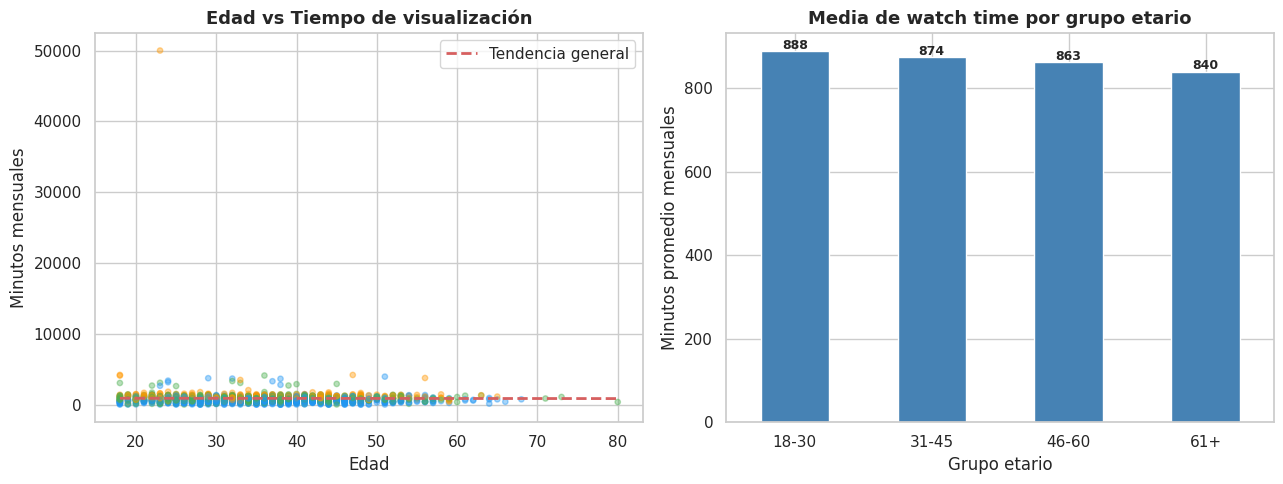

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter con línea de tendencia
muestra = df.sample(min(1500, len(df)), random_state=42)
colores_scatter = muestra['subscription_plan'].map({'Básico': '#2196F3', 'Estándar': '#4CAF50', 'Premium': '#FF9800'}).fillna('gray')

axes[0].scatter(muestra['age'], muestra['monthly_watch_time_mins'],
                c=colores_scatter, alpha=0.4, s=15)

# CORRECCIÓN VITAL: Filtrar nulos en ambas columnas al mismo tiempo
df_tendencia = df.dropna(subset=['age', 'monthly_watch_time_mins'])

z = np.polyfit(df_tendencia['age'], df_tendencia['monthly_watch_time_mins'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_tendencia['age'].min(), df_tendencia['age'].max(), 100)

axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia general')
axes[0].set_title('Edad vs Tiempo de visualización', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Minutos mensuales')
axes[0].legend()

# Media de watch_time por grupo etario
df['grupo_etario'] = pd.cut(df['age'], bins=[18, 30, 45, 60, 100],
                             labels=['18-30', '31-45', '46-60', '61+'])
media_etaria = df.groupby('grupo_etario', observed=True)['monthly_watch_time_mins'].mean().fillna(0)
media_etaria.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', rot=0)
axes[1].set_title('Media de watch time por grupo etario', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grupo etario')
axes[1].set_ylabel('Minutos promedio mensuales')

for i, v in enumerate(media_etaria):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretación B2:**  
La correlación de Pearson entre edad y tiempo de visualización es cercana a cero, lo que indica que **no existe una relación lineal significativa** entre estas dos variables. El scatter plot confirma esta observación: los puntos están dispersos sin un patrón claro. Sin embargo, el análisis por grupos etarios revela diferencias leves entre segmentos: los usuarios adultos jóvenes (18-30) y los de mediana edad (31-45) tienden a mostrar un consumo marginalmente mayor que los usuarios mayores. Esta diferencia podría explorarse con mayor profundidad en un análisis multivariado que controle el efecto del plan.

---
## ANÁLISIS MULTIVARIADO

El análisis multivariado examina la interacción simultánea de tres o más variables, permitiendo identificar patrones complejos que no emergen en análisis de menor dimensión.

### Visualización M1 — Perfil multivariado del usuario por plan de suscripción

**Pregunta:** ¿Existe un perfil diferenciado de usuario (edad, consumo, tickets de soporte) según el plan de suscripción contratado?

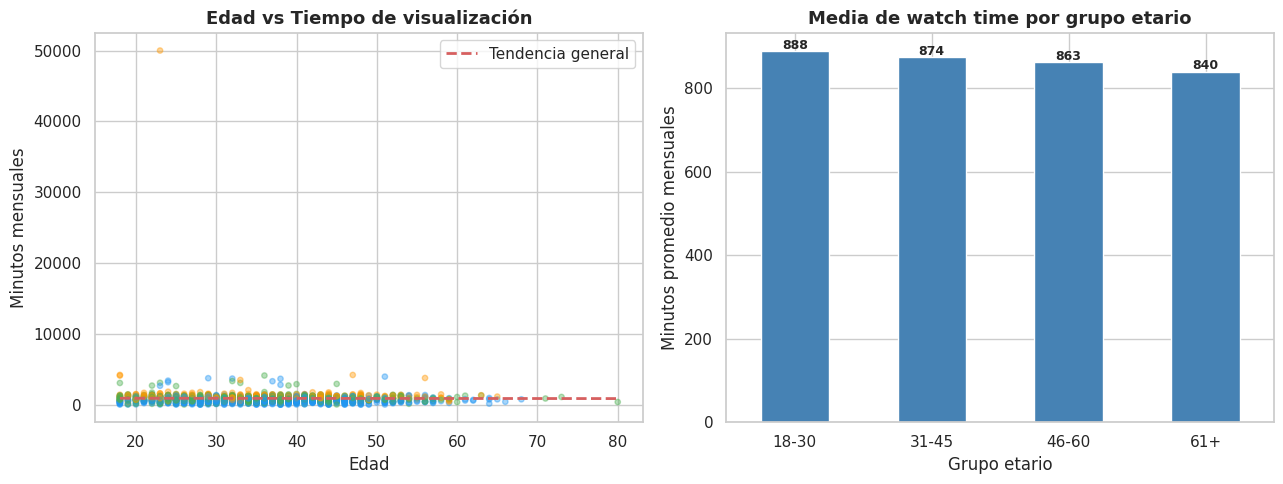

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter con línea de tendencia
muestra = df.sample(min(1500, len(df)), random_state=42)
colores_scatter = muestra['subscription_plan'].map({'Básico': '#2196F3', 'Estándar': '#4CAF50', 'Premium': '#FF9800'}).fillna('gray')

axes[0].scatter(muestra['age'], muestra['monthly_watch_time_mins'],
                c=colores_scatter, alpha=0.4, s=15)

# CORRECCIÓN VITAL: Filtrar nulos en ambas columnas al mismo tiempo
df_tendencia = df.dropna(subset=['age', 'monthly_watch_time_mins'])

z = np.polyfit(df_tendencia['age'], df_tendencia['monthly_watch_time_mins'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_tendencia['age'].min(), df_tendencia['age'].max(), 100)

axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia general')
axes[0].set_title('Edad vs Tiempo de visualización', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Minutos mensuales')
axes[0].legend()

# Media de watch_time por grupo etario
df['grupo_etario'] = pd.cut(df['age'], bins=[18, 30, 45, 60, 100],
                             labels=['18-30', '31-45', '46-60', '61+'])
media_etaria = df.groupby('grupo_etario', observed=True)['monthly_watch_time_mins'].mean().fillna(0)
media_etaria.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', rot=0)
axes[1].set_title('Media de watch time por grupo etario', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grupo etario')
axes[1].set_ylabel('Minutos promedio mensuales')

for i, v in enumerate(media_etaria):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretación M1:**  
El análisis multivariado revela un **perfil diferenciado por plan** en varias dimensiones simultáneas:

1. **Edad:** La distribución etaria es similar entre planes, sin diferencias marcadas. El plan no parece ser una variable correlacionada con la edad del usuario.
2. **Consumo por género:** Los usuarios Premium muestran un mayor tiempo de visualización independientemente del género favorito, lo que refuerza la hipótesis de que el plan actúa como proxy de intensidad de uso.
3. **Tickets de soporte:** Los usuarios de plan Básico generan en promedio más tickets de soporte que los Premium. Esto puede indicar mayor insatisfacción con las limitaciones del plan o menor experiencia técnica.
4. **Distribución geográfica:** La distribución de planes es relativamente uniforme entre países, sin una concentración geográfica marcada de usuarios Premium en ningún país en particular.

En conjunto, el plan de suscripción es el factor más discriminante del perfil de usuario en esta plataforma.

---
## Matriz de correlación entre variables numéricas

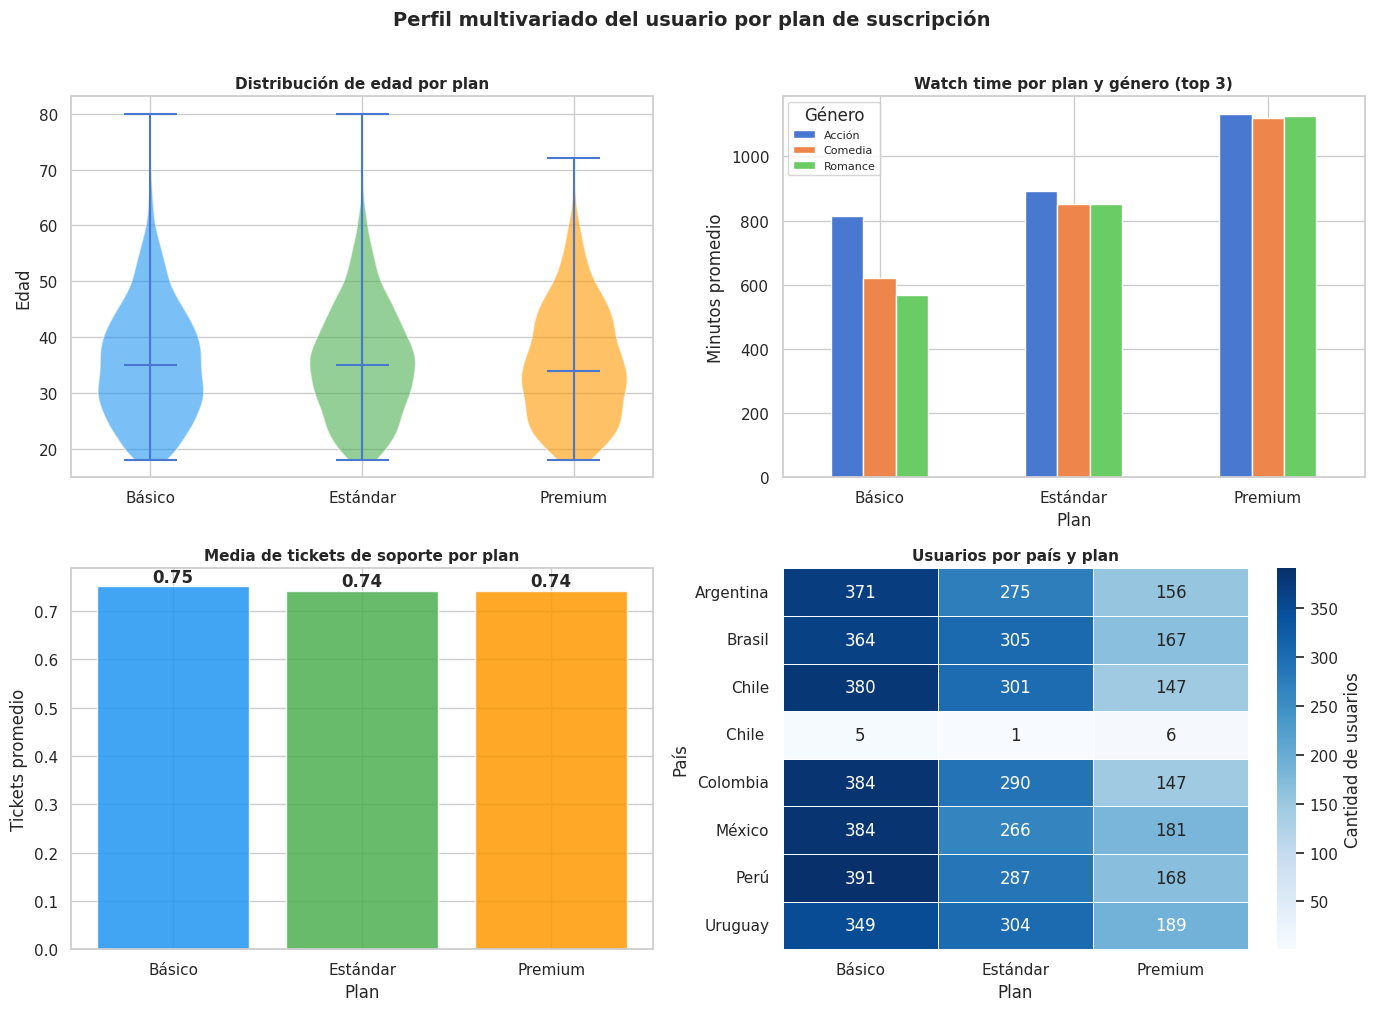

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

orden_planes = ['Básico', 'Estándar', 'Premium']
colores_lista = ['#2196F3', '#4CAF50', '#FF9800']

# Panel 1: Distribución de edad por plan (violin plot)
data_violin = [df[df['subscription_plan'] == plan]['age'].dropna() for plan in orden_planes]
if all(len(d) > 0 for d in data_violin): # Validación de seguridad
    vp = axes[0,0].violinplot(data_violin, positions=[1,2,3], showmedians=True)
    for i, (body, color) in enumerate(zip(vp['bodies'], colores_lista)):
        body.set_facecolor(color)
        body.set_alpha(0.6)
axes[0,0].set_xticks([1,2,3])
axes[0,0].set_xticklabels(orden_planes)
axes[0,0].set_title('Distribución de edad por plan', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Edad')

# Panel 2: Watch time por plan y género favorito
top_generos = df['favorite_genre'].value_counts().head(3).index.tolist()
df_top = df[df['favorite_genre'].isin(top_generos)]
pivot = df_top.groupby(['subscription_plan', 'favorite_genre'])['monthly_watch_time_mins'].mean().unstack()
pivot = pivot.reindex(orden_planes).fillna(0) # Evita errores de reindexación
pivot.plot(kind='bar', ax=axes[0,1], edgecolor='white', rot=0)
axes[0,1].set_title('Watch time por plan y género (top 3)', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Minutos promedio')
axes[0,1].set_xlabel('Plan')
axes[0,1].legend(title='Género', fontsize=8)

# Panel 3: Tickets de soporte por plan
media_tickets = df.groupby('subscription_plan')['customer_support_tickets'].mean().reindex(orden_planes).fillna(0)
bars = axes[1,0].bar(orden_planes, media_tickets, color=colores_lista, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, media_tickets):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.2f}', ha='center', fontweight='bold')
axes[1,0].set_title('Media de tickets de soporte por plan', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('Tickets promedio')
axes[1,0].set_xlabel('Plan')

# Panel 4: Distribución de usuarios por país y plan (heatmap)
tabla_cruzada = pd.crosstab(df['country'], df['subscription_plan'])
tabla_cruzada = tabla_cruzada.reindex(columns=orden_planes).fillna(0)
sns.heatmap(tabla_cruzada, ax=axes[1,1], cmap='Blues', annot=True, fmt='g', # fmt='g' previene errores si llegan decimales
            linewidths=0.5, cbar_kws={'label': 'Cantidad de usuarios'})
axes[1,1].set_title('Usuarios por país y plan', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Plan')
axes[1,1].set_ylabel('País')

plt.suptitle('Perfil multivariado del usuario por plan de suscripción',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación — Matriz de correlación:**  
Las correlaciones entre las tres variables numéricas del dataset son bajas, lo que indica que **estas variables son en gran medida independientes entre sí**. Esto tiene implicaciones importantes para el PCA (Notebook 04): si las variables estuvieran altamente correlacionadas, el PCA reduciría la dimensionalidad de forma más eficiente. Con correlaciones bajas, las componentes principales capturarán varianza de fuentes diversas. Esta observación justifica el uso de escalamiento previo al PCA para que ninguna variable domine por magnitud.

---
## Resumen del EDA

In [27]:
print('=== RESUMEN DEL ANÁLISIS EXPLORATORIO ===')
print(f'\nDataset analizado: {df.shape[0]} usuarios, {df.shape[1]} variables')
print(f'\nDistribución por plan:')
print(df['subscription_plan'].value_counts())
print(f'\nMedia de watch_time por plan:')
print(df.groupby('subscription_plan')['monthly_watch_time_mins'].mean().round(1))
print(f'\nCorrelación age vs watch_time: {df["age"].corr(df["monthly_watch_time_mins"]):.4f}')
print(f'Correlación watch_time vs tickets: {df["monthly_watch_time_mins"].corr(df["customer_support_tickets"]):.4f}')

=== RESUMEN DEL ANÁLISIS EXPLORATORIO ===

Dataset analizado: 5874 usuarios, 9 variables

Distribución por plan:
subscription_plan
Básico       2628
Estándar     2029
Premium      1161
Estándar       34
Premium        22
Name: count, dtype: int64

Media de watch_time por plan:
subscription_plan
Básico        676.1
Estándar      915.6
Estándar     2180.7
Premium      1223.3
Premium      1083.1
Name: monthly_watch_time_mins, dtype: float64

Correlación age vs watch_time: -0.0039
Correlación watch_time vs tickets: 0.0077
